## Redo Paper (include new results )

In [1]:
import os.path as op    
import nibabel as nib
import numpy as np
import pandas as pd
import os

bids_folder = '/mnt_03/ds-dnumrisk'
group_df = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
plot_folder = op.join(BIDS_ROOT_LARGE, 'paper_materials')
os.makedirs(plot_folder, exist_ok=True)

param = 'r2' # 
nPRF_folder = op.join(bids_folder, 'derivatives/encoding_model.denoise')

subList = np.arange(1, 67) # 1-66
subList = subList[subList != 3] # remove sub-09
group_df = group_df.loc[subList]


In [2]:
# house style + shared plotting helpers (see prep_results/plotting.py)
import seaborn as sns

from parietal_patterns.prep_results.plotting import (
    set_style, render_surf_panel, plot_group_comparison_panel,
    add_panel_letter, add_subpanel_label,
    GROUP_LABELS, GROUP_ORDER, GROUP_PALETTE,
)

set_style()
group_labels = GROUP_LABELS
group_palette = GROUP_PALETTE

In [3]:
from parietal_patterns.utils.surfaces import get_NPC_mask, get_basic_mask
npc_mask = get_NPC_mask(space='fsaverage5', hemi='both') # (20484,)
npc_mask_L = get_NPC_mask(space='fsaverage5', hemi='L') 
npc_mask_R = get_NPC_mask(space='fsaverage5', hemi='R')

# not needed now
brain_mask, _ = get_basic_mask() # default is fsaverage5, hemi='both' (20484,)
npc_mask_cortex = npc_mask[brain_mask] # 59412
npc_mask_cortex.shape

(18715,)

In [4]:
hemi = 'R'
rows_DD = []
rows_HC = []

for sub in subList:
    nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

    nPRF_NPC = nPRFmap_fsav5#[npc_mask]
    
    if group_df.loc[sub, 'group'] == 0:
        rows_HC.append(nPRF_NPC)
    elif group_df.loc[sub, 'group'] == 1:
        rows_DD.append(nPRF_NPC)

df_HC = pd.DataFrame(rows_HC, index=pd.Index(subList, name='subject')[group_df['group'] == 0])
df_DD = pd.DataFrame(rows_DD, index=pd.Index(subList, name='subject')[group_df['group'] == 1])

df_HC.mean(axis=0).shape, df_DD.mean(axis=0).shape

((20484,), (20484,))

In [5]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt

r2_min_thres = 0.02

cmap = 'magma' 
view = (30, 220) if hemi == 'L' else (30, -30) # (elev, azim) in degrees -- tweak freely
vmin = 0.02
vmax = 0.03

fsaverage = fetch_surf_fsaverage('fsaverage5') 


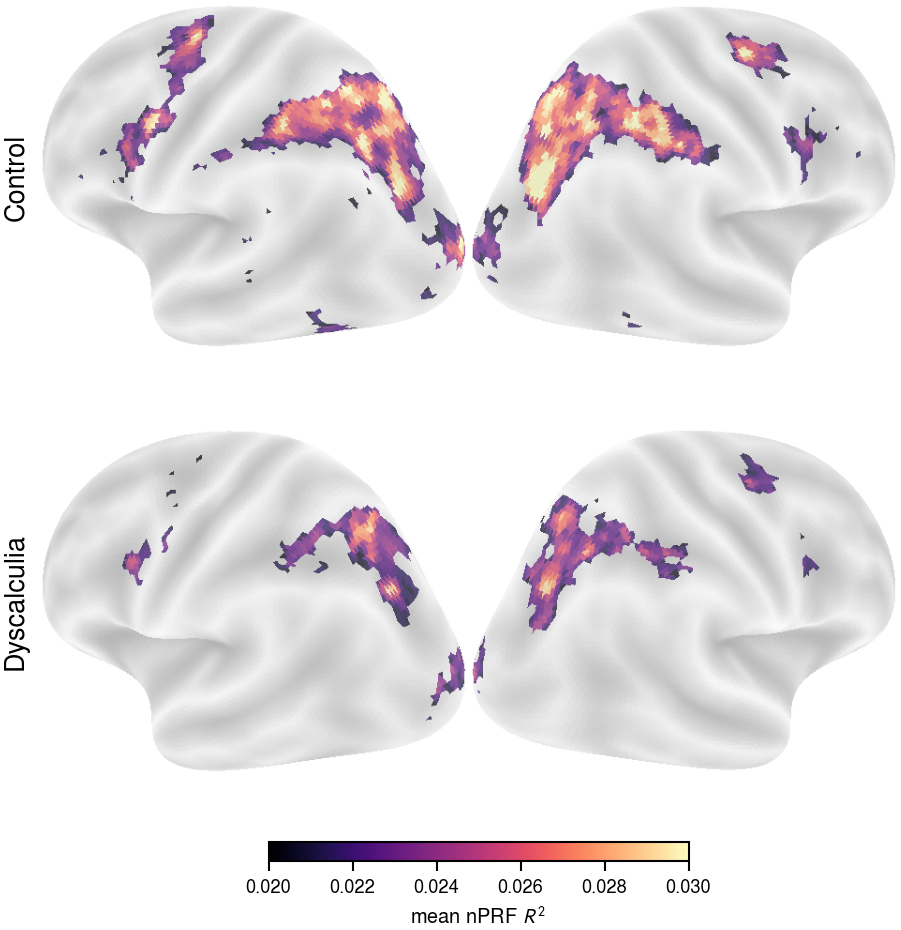

In [6]:
view_L = (30, 30 + (360/2))
view_R = (30, -30)

col_specs = [('L', fsaverage.infl_left, fsaverage.sulc_left, 0, view_L),
             ('R', fsaverage.infl_right, fsaverage.sulc_right, 1, view_R)]
row_specs = [('Control', df_HC), ('Dyscalculia', df_DD)]

panel_imgs = {}
for hemi, surf_mesh_col, bg_map_col, i_hemi, view in col_specs:
    for label, df_group in row_specs:
        cortex_map = df_group.mean(axis=0).values # [npc_mask]
        cortex_map[cortex_map < r2_min_thres] = np.nan
        surf_map_hemi = np.split(cortex_map, 2)[i_hemi]
        panel_imgs[(label, hemi)] = render_surf_panel(surf_mesh_col, bg_map_col, surf_map_hemi, view, cmap, vmin, vmax)

fig, axes = plt.subplots(2, 2, figsize=(7, 6.5))
for i_row, (label, _) in enumerate(row_specs):
    for i_col, (hemi, *_) in enumerate(col_specs):
        ax = axes[i_row, i_col]
        ax.imshow(panel_imgs[(label, hemi)])
        ax.axis('off')
    axes[i_row, 0].text(-0.05, 0.5, label, transform=axes[i_row, 0].transAxes,
                         rotation=90, va='center', ha='center', fontsize=13)

fig.subplots_adjust(wspace=0.0, hspace=0.05, bottom=0.1, top=0.95, left=0.08)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar_ax = fig.add_axes([0.3, 0.04, 0.4, 0.02])
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='mean nPRF $R^2$')

fig.savefig(op.join(plot_folder, 'ch3_nPRF_R2_NPC_group_hemi.pdf'), bbox_inches='tight')
plt.show()

In [7]:
r2_area_thres = 0.02
rows = []
for sub in subList:
    nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

    nPRF_NPC = nPRFmap_fsav5[npc_mask]
    nPRF_NPC_L = nPRFmap_fsav5[npc_mask_L]
    npRF_NPC_R = nPRFmap_fsav5[npc_mask_R]
    rows.append({'mean_R2': nPRF_NPC.mean(),
                 'median_R2': np.median(nPRF_NPC),
                f'area(r2>{r2_area_thres})': (nPRF_NPC > r2_area_thres).sum(),
                })

df = pd.DataFrame(rows, index=pd.Index(subList, name='subject')).join(group_df, how='inner').set_index('group', append=True)
#df.to_csv(op.join(PHENOTYPE_DIR, 'nPRF_R2area.csv'))

In [8]:
from parietal_patterns.utils.statistics import between_group_comparison

measures = [c for c in df.columns]  # mean_R2, median_R2, area(r2>...)

df_plot = df.reset_index()
df_plot['group_label'] = df_plot['group'].map(group_labels)

stats_by_measure = {}
for m in measures:
    stat, stats_term = between_group_comparison(df, m, group_names=[0, 1])
    stats_by_measure[m] = (stat, stats_term)
    print(f'{m}: {stats_term} = {stat.statistic:.2f}, p = {stat.pvalue:.3f}')

mean_R2: U(32, 33) = 705.00, p = 0.021
median_R2: U(32, 33) = 717.00, p = 0.013
area(r2>0.02): t(63) = 2.46, p = 0.016


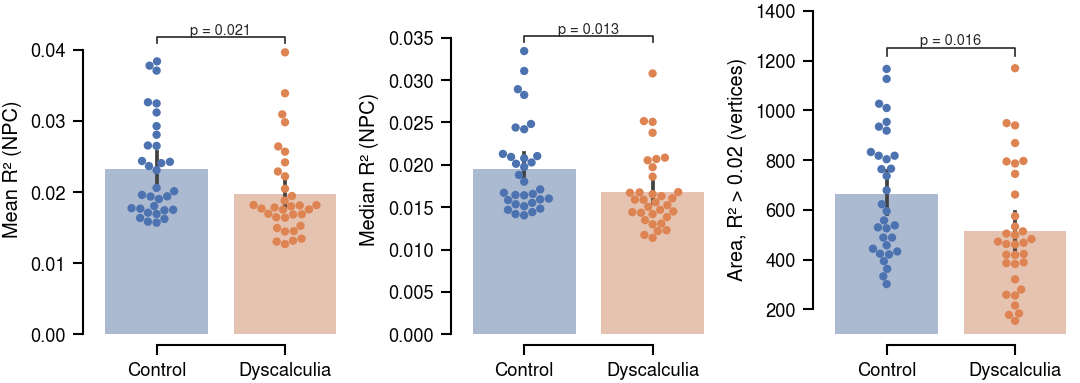

In [9]:
# Robustness check: three summary measures of nPRF R2 in NPC, Control vs Dyscalculia.
ylabels = {
    'mean_R2': 'Mean R² (NPC)',
    'median_R2': 'Median R² (NPC)',
}
for m in measures:
    if m not in ylabels:
        ylabels[m] = f'Area, R² > {r2_area_thres} (vertices)'

# zoomed y-axis for the area measure only: its min (154) is far from 0, so a
# from-zero axis wastes space; 100 crops the empty margin without clipping data
ymins = {'mean_R2': None, 'median_R2': None, f'area(r2>{r2_area_thres})': 100}

fig, axes = plt.subplots(1, 3, figsize=(7.25, 2.6), constrained_layout=True)

for ax, m in zip(axes, measures):
    stat, stats_term = stats_by_measure[m]
    plot_group_comparison_panel(ax, df_plot, m, ylabels[m], stat, ymin=ymins[m])

sns.despine(fig=fig, offset=5, trim=True)
fig.savefig(op.join(plot_folder, 'ch3_nPRF_R2_group_comparison_measures.pdf'))
fig.savefig(op.join(plot_folder, 'ch3_nPRF_R2_group_comparison_measures.svg'))
plt.show()

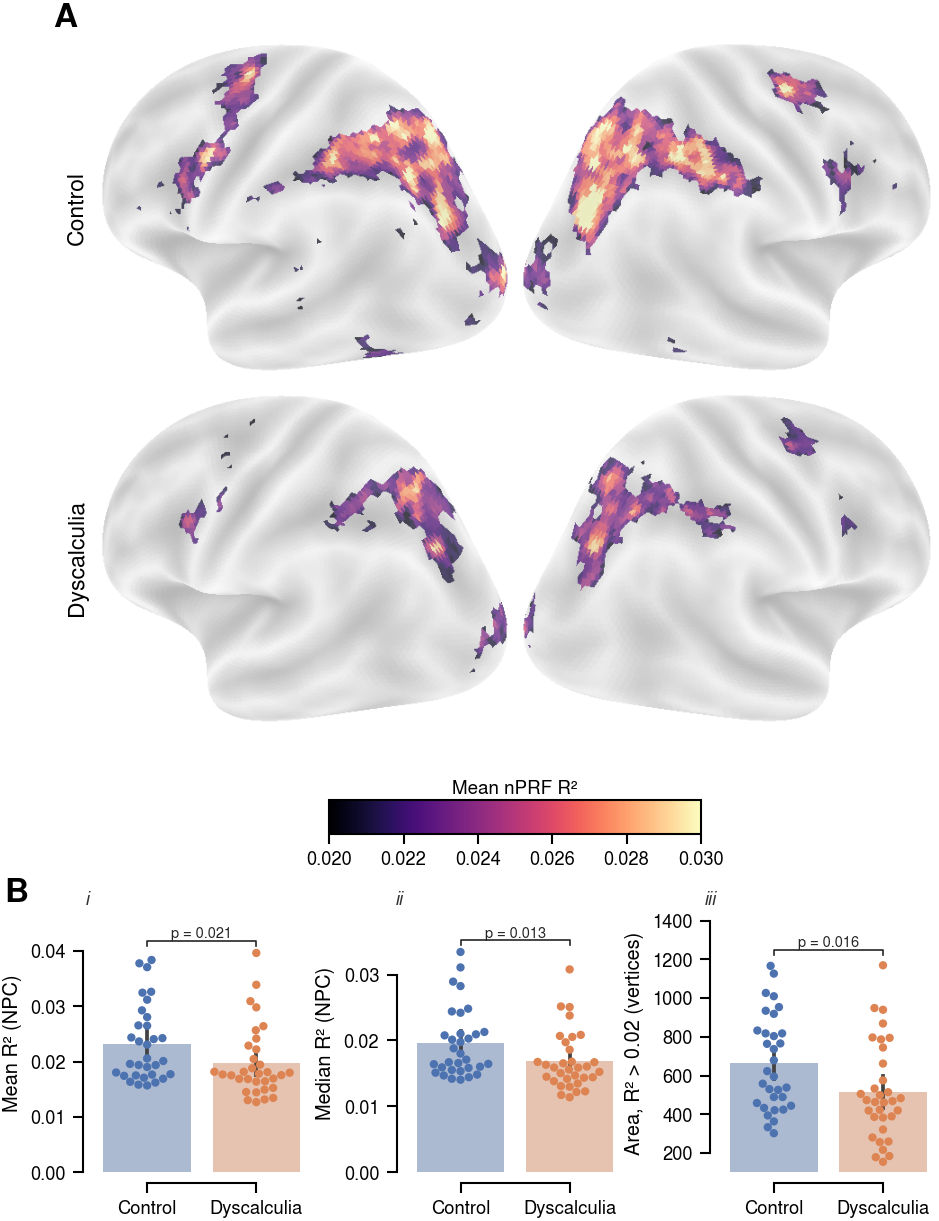

In [10]:
# Combined figure: (A) group-mean nPRF R2 on the NPC surface, (B.i-iii) the three
# robustness-check measures. Journal double-column width (7.25").
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(7.25, 9.8))
# rows: (A) surfaces | gap A->B | colorbar | gap cbar->bars | (B) bars
gs = GridSpec(5, 1, height_ratios=[6.1, 0.55, 0.3, 0.6, 2.3], hspace=0.03, figure=fig)

# --- (A) surfaces, 2 (group) x 2 (hemi) ---
gs_top = gs[0].subgridspec(2, 2, wspace=0.0, hspace=0.05)
axes_top = [[fig.add_subplot(gs_top[i, j]) for j in range(2)] for i in range(2)]

for i_row, (label, _) in enumerate(row_specs):
    for i_col, (hemi_, *_) in enumerate(col_specs):
        ax = axes_top[i_row][i_col]
        ax.imshow(panel_imgs[(label, hemi_)])
        ax.axis('off')
    axes_top[i_row][0].text(-0.05, 0.5, label, transform=axes_top[i_row][0].transAxes,
                             rotation=90, va='center', ha='center', fontsize=11)

add_panel_letter(axes_top[0][0], 'A', dx=-0.05, dy=1.02, fontsize=16)
# gs[1] is left empty: extra breathing room between panel A and panel B.

gs_cbar = gs[2].subgridspec(1, 3, width_ratios=[1, 2, 1])
cbar_ax = fig.add_subplot(gs_cbar[0, 1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar_ax.set_title('Mean nPRF R²', fontsize=9, pad=3)  # title, not xlabel: keeps it above the
                                                        # bar, clear of the row below
# gs[3] is left empty: spacer so the colorbar's tick labels never collide with
# panel B's sub-panel labels / stat brackets.

# --- (B.i-iii) robustness-check measures ---
gs_bottom = gs[4].subgridspec(1, 3, wspace=0.45)
axes_bottom = [fig.add_subplot(gs_bottom[0, k]) for k in range(3)]

# zoomed y-axis for the area measure only: its min (154) is far from 0, so a
# from-zero axis wastes space; 100 crops the empty margin without clipping data
ymins = {'mean_R2': None, 'median_R2': None, f'area(r2>{r2_area_thres})': 100}

for k, (ax, m) in enumerate(zip(axes_bottom, measures)):
    stat, stats_term = stats_by_measure[m]
    plot_group_comparison_panel(ax, df_plot, m, ylabels[m], stat, ymin=ymins[m])
    add_subpanel_label(ax, ['i', 'ii', 'iii'][k], dx=-0.02, dy=1.02)
    sns.despine(ax=ax, offset=5, trim=True)

# 'B' sits further out than the leftmost panel's 'i' sub-label so the two don't overlap
add_panel_letter(axes_bottom[0], 'B', dx=-0.3, dy=1.02, fontsize=16)

fig.savefig(op.join(plot_folder, 'ch3_nPRF_R2_combined_fig1.pdf'))
fig.savefig(op.join(plot_folder, 'ch3_nPRF_R2_combined_fig1.svg'))
plt.show()